# DART prior-innovation component profiles

This notebook focuses on the two complementary components of prior observation mismatch across experiments and pressure levels for U, V, temperature, and humidity: the mean prior innovation (systematic component) and centered innovation standard deviation (random component). It provides the observation-space starting point for the state-update profiles in notebook 06 and the spatial case study in notebook 07.

The aggregate NIS proxy is retained in the processed cache only as a secondary diagnostic. It is not included in the primary figure because it largely repeats the calibration information already presented by Total Spread/RMSE in the preceding observation-diagnostic analysis. CAM80 provides an observation-space benchmark; direct cross-notebook comparisons use the shared DART10, DART20, and DART40 experiments. The common-S0 period aligns with notebook 06, while the S1 innovation products cover the full May period and notebook 06 uses 17–31 May. The User setup selects which data sets and regions to plot; Global (GB) common-S0 is the presentation default and is not selected from the diagnostic values.

## 1. Libraries


In [23]:
import logging
import warnings
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


## 2. User setup


In [24]:
# =============================================================================
# TOP-LEVEL PATH PARAMETERS
# =============================================================================
INPUT_DATA_ROOT = Path("/compyfs/zhan391/v3_dart_cda_scratch")
DART_DATA_ROOT = INPUT_DATA_ROOT
WORK_DIR = Path("/compyfs/zhan391/work_package/e3sm_dart_analysis")
DIAGNOSTIC_OUTPUT_ROOT = Path("/compyfs/www/zhan391/e3sm_dart/diag_dart_2026")
WORKFLOW_NAME = "analysis_atm_da"
DIAG_PATH_TEMPLATES = {
    "cam": str(INPUT_DATA_ROOT / "%(RUNNAME)" / "%(CASENAME)" / "cam" / "dart_diagnostics" / "%(DIAG)"),
    "e3sm": str(INPUT_DATA_ROOT / "%(RUNNAME)" / "%(CASENAME)" / "eam" / "dart_diagnostics" / "%(DIAG)"),
}
CAM_LAYOUT_EXPERIMENTS = {"CAM80-S0", "CAM80-S1"}
USER_EXPERIMENTS = {
    "CAM80-S0": {"run": "f.e21.FHIST_BGC.f09_025.CAM6assim.011", "key": "dart_en80", "alias": "CAM6EN80", "period": "2011121600-2012010100"},
    "CAM80-S1": {"run": "f.e22.FHIST_BGC.f09_025.CAM6assim.011", "key": "dart_en80", "alias": "CAM6EN80S1", "period": "2012050100-2012060100"},
    "CTRL10-S0": {"run": "CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy", "key": "dart_en10", "alias": "CTRLEN10", "period": "2011121600-2012010100"},
    "DART10-S0": {"run": "DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy", "key": "dart_en10", "alias": "DARTEN10", "period": "2011121600-2012010100"},
    "DART20-S0": {"run": "DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy", "key": "dart_en20", "alias": "DARTEN20", "period": "2011121600-2012010100"},
    "DART40-S0": {"run": "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy", "key": "dart_en40", "alias": "DARTEN40", "period": "2011121600-2012010100"},
    "DART40-S1": {"run": "DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy", "key": "dart_en40", "alias": "DARTEN40S1", "period": "2012050100-2012060100"},
}
USER_DIAG_SETS = ("obs_seq", "obs_diag", "obs_common", "closest_member", "cam6_common")
USER_EXPERIMENT_OVERRIDES = {}
for experiment_name, experiment in USER_EXPERIMENTS.items():
    layout = "cam" if experiment_name in CAM_LAYOUT_EXPERIMENTS else "e3sm"
    experiment["path_template"] = DIAG_PATH_TEMPLATES[layout]

S0_EXPERIMENTS = ("CAM80-S0", "DART10-S0", "DART20-S0", "DART40-S0")
S1_EXPERIMENTS = ("CAM80-S1", "DART40-S1")
PROFILE_MODE_CONFIGS = {
    "obs_space_s0": {"diag_set": "diag2", "experiments": S0_EXPERIMENTS},
    "obs_space_s1": {"diag_set": "diag2", "experiments": S1_EXPERIMENTS},
    "common_s0": {"diag_set": "diag5", "experiments": S0_EXPERIMENTS},
    "common_s1": {"diag_set": "diag5", "experiments": S1_EXPERIMENTS},
}
PROFILE_MODE_LABELS = {
    "obs_space_s0": "Available observations (S0)",
    "obs_space_s1": "Available observations (S1)",
    "common_s0": "Common observations (S0)",
    "common_s1": "Common observations (S1)",
}
AVAILABLE_PROFILE_MODES = ("obs_space_s0", "obs_space_s1", "common_s0", "common_s1")
REGION_NAMES = {
    "NH": "Northern Hemisphere",
    "SH": "Southern Hemisphere",
    "Global": "Global",
}
REGION_PLOT_LABELS = {"NH": "NH", "SH": "SH", "Global": "GB"}
AVAILABLE_REGIONS = ("NH", "SH", "Global")

# Plot-selection controls. Add entries to either tuple to generate several figures.
PLOT_MODES = ("common_s0",)
PLOT_REGIONS = ("Global",)  # Global is labeled GB in the figure
DISPLAY_MODE = "common_s0"
DISPLAY_REGION = "Global"

if not set(PLOT_MODES).issubset(AVAILABLE_PROFILE_MODES):
    raise ValueError(f"PLOT_MODES must be selected from {AVAILABLE_PROFILE_MODES}.")
if not set(PLOT_REGIONS).issubset(AVAILABLE_REGIONS):
    raise ValueError(f"PLOT_REGIONS must be selected from {AVAILABLE_REGIONS}.")
if DISPLAY_MODE not in PLOT_MODES or DISPLAY_REGION not in PLOT_REGIONS:
    raise ValueError("DISPLAY_MODE and DISPLAY_REGION must also be selected for plotting.")
PROFILE_VARIABLES = {
    "U_WIND": {"label": "U", "unit": "m s$^{-1}$"},
    "V_WIND": {"label": "V", "unit": "m s$^{-1}$"},
    "Temperature": {"label": "T", "unit": "$^\\circ$C"},
    "Humidity": {"label": "Q", "unit": "g kg$^{-1}$"},
}
PLOT_METRICS = ("bias", "sd")
METRIC_LABELS = {
    "bias": "Innovation bias",
    "sd": "Innovation SD",
    "rmse": "Innovation RMSE",
    "nis_proxy": "Aggregate NIS proxy",
}
SHOW = False
SHOW_DEFAULT = True
SAVE = True
FIGURE_TITLE_TEMPLATE = None
# Example: FIGURE_TITLE_TEMPLATE = "{region} | Prior-innovation profiles | {mode}"
PANEL_WIDTH = 16
PANEL_HEIGHT = 12
fontz = 24  # Base font size; all figure text scales from this value.
LINE_WIDTH = 2.2
MARKER_SIZE = 5.5
DPI = 300
USE_DASK = True
DASK_CHUNKS = {"time": 31, "copy": -1, "plevel": -1, "region": 1}
PERSIST_MEANS = False
EXPECTED_TIME_INCREMENT_DAYS = 0.25

FORCE_COMPUTE = False
CACHE_SCHEMA_VERSION = 1


## 3. Project setup


In [25]:
import sys

DIAGNOSTIC_DIR = WORK_DIR / "diagnostic"
if not DIAGNOSTIC_DIR.is_dir():
    raise FileNotFoundError(f"Diagnostic work directory not found: {DIAGNOSTIC_DIR}")
if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

from configs.output_paths import workflow_output_dirs

WORKFLOW_DATA_DIR, WORKFLOW_FIGURE_DIR = workflow_output_dirs(
    WORKFLOW_NAME,
    output_root=DIAGNOSTIC_OUTPUT_ROOT,
)
DIAG_DATA_DIR = DIAGNOSTIC_OUTPUT_ROOT / "data"
DIAG_FIGURE_DIR = DIAGNOSTIC_OUTPUT_ROOT / "figure"
from util.dask_helpers import configure_dask, persist_if_dask
from util.dart_observation_diagnostics import DartObsDiagReader
from configs.analysis_da_experiment_config import extract_obs_diag_config

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
LOGGER = logging.getLogger("prior_innovation_profiles")
plt.rcParams["savefig.pad_inches"] = 0.03

PROFILE_CACHE_DIR = WORKFLOW_DATA_DIR / "obs_diagnostics" / "prior_innovation_profiles"
PROFILE_FIGURE_DIR = WORKFLOW_FIGURE_DIR / "obs_diagnostics" / "prior_innovation_profiles"


## 4. Input validation and dataset discovery
Resolve the files required by each mode before loading diagnostic arrays. Missing files are reported together.

### Observation-operator alignment and prior-space pairing
Match pressure-level nonsatellite observations by the same U/V/T/Q variable names used by the profile workflow. `VPguess` selects prior diagnostics; the selected region name must match the DART `region_names` coordinate exactly.

### Innovation components ($d$, bias, and variance terms)
The period-aggregated `obs_diag` product does not retain each paired $y$ and $H\bar{x}^f$. Its `bias` is the mean prior innovation, `rmse` is the innovation root-mean-square, and `totalspread` represents prior-plus-observation-error uncertainty. The separate $\sigma_f^2$ and $\sigma_o^2$ terms and sample-level $z$ cannot be reconstructed from these aggregates.

In [26]:
def extract_exp_info():
    return extract_obs_diag_config(
        experiments=USER_EXPERIMENTS,
        data_path=INPUT_DATA_ROOT,
        diag_sets=USER_DIAG_SETS,
        experiment_overrides=USER_EXPERIMENT_OVERRIDES,
    )


def make_reader_config(exp_info):
    config = dict(exp_info["global"])
    if USE_DASK:
        config.update({
            "dask_chunks": DASK_CHUNKS,
            "return_dask": True,
            "persist_arrays": False,
        })
    return config


def validate_profile_inputs(reader, experiments, diag_set):
    missing = []
    for experiment_name, experiment in experiments.items():
        directory, filename = reader.resolve_dart_file_path(
            experiment, experiment_name, diag_set, experiment["period"]
        )
        file_path = Path(directory) / filename
        if not file_path.is_file():
            missing.append(file_path)
    if missing:
        details = "\n".join(f"  - {path}" for path in missing)
        raise FileNotFoundError("Missing DART innovation-diagnostic inputs:\n" + details)


def find_profile_matches(reader, variable_name):
    observations = reader.extract_obs_group()
    matches = [
        (group, level_name, observation_name)
        for group, levels in observations.items()
        if "Satellite" not in group
        for level_name, variables in levels.items()
        if "plev" in level_name.lower() or "pressure" in level_name.lower()
        for observation_name in variables
        if variable_name.lower() in observation_name.lower()
    ]
    return matches


def as_profile_array(values):
    if hasattr(values, "compute"):
        values = values.compute()
    if hasattr(values, "values"):
        values = values.values
    return np.asarray(values, dtype=float).reshape(-1)

## 5. Derive and aggregate innovation components
For each observation type and pressure layer, DART supplies aggregate bias $\mu_d$, innovation RMSE $r=\sqrt{E[d^2]}$, total spread $s$, and assimilated count $N$. The primary diagnostics separate systematic and random mismatch using $\mathrm{SD}(d)=\sqrt{\max(r^2-\mu_d^2,0)}$. When bias is small, centered innovation SD will resemble RMSE; its value here is the explicit decomposition rather than an independent error measure.

### Aggregate by pressure level and region
Pool sufficient statistics across compatible observation types with $N$ weights:

- $\mu_d=\sum N_i\mu_i/\sum N_i$
- $E[d^2]=\sum N_i r_i^2/\sum N_i$
- $E[\sigma_f^2+\sigma_o^2]_{\mathrm{proxy}}=\sum N_i s_i^2/\sum N_i$
- Secondary cached **aggregate NIS proxy** $=E[d^2]/E[\sigma_f^2+\sigma_o^2]_{\mathrm{proxy}}$
- Secondary normalized mean and variance proxies are retained for optional checks.

The normalized proxies are ratios of aggregate moments, not exact $E[z]$, $\mathrm{Var}(z)$, or $E[z^2]$. They are deliberately excluded from the main figure because their calibration message overlaps strongly with Total Spread/RMSE. Exact per-observation normalized statistics require observation-level prior diagnostics.

In [27]:
def pool_observation_type_profiles(type_profiles, variable_name, experiment_name):
    if not type_profiles:
        raise ValueError(f"No observation types to pool for {variable_name}/{experiment_name}.")

    reference_pressure = np.asarray(type_profiles[0]["pressure"], dtype=float).reshape(-1)
    fields = ("bias", "rmse", "totalspread", "nused")
    stacked = {field: [] for field in fields}

    for profile in type_profiles:
        pressure = np.asarray(profile["pressure"], dtype=float).reshape(-1)
        if pressure.shape != reference_pressure.shape or not np.allclose(pressure, reference_pressure, equal_nan=True):
            raise ValueError(f"Pressure-level mismatch for {variable_name}/{experiment_name}.")
        for field in fields:
            values = as_profile_array(profile[field])
            if values.size == 0:
                values = np.full(reference_pressure.shape, np.nan)
            if values.shape != reference_pressure.shape:
                raise ValueError(
                    f"{field} shape mismatch for {variable_name}/{experiment_name}: "
                    f"expected {reference_pressure.shape}, got {values.shape}."
                )
            stacked[field].append(values)

    bias = np.stack(stacked["bias"])
    rmse = np.stack(stacked["rmse"])
    totalspread = np.stack(stacked["totalspread"])
    nused = np.stack(stacked["nused"])
    finite_counts = np.isfinite(nused) & (nused > 0)
    valid_innovation = (
        finite_counts & np.isfinite(bias) & np.isfinite(rmse) & (rmse >= 0)
    )
    valid_nis = (
        finite_counts & np.isfinite(rmse) & (rmse >= 0)
        & np.isfinite(totalspread) & (totalspread > 0)
    )

    innovation_weights = np.where(valid_innovation, nused, 0.0)
    innovation_weight_sum = innovation_weights.sum(axis=0)
    pooled_bias = np.divide(
        (innovation_weights * np.where(valid_innovation, bias, 0.0)).sum(axis=0),
        innovation_weight_sum,
        out=np.full(reference_pressure.shape, np.nan),
        where=innovation_weight_sum > 0,
    )
    pooled_innovation_second_moment = np.divide(
        (innovation_weights * np.where(valid_innovation, rmse ** 2, 0.0)).sum(axis=0),
        innovation_weight_sum,
        out=np.full(reference_pressure.shape, np.nan),
        where=innovation_weight_sum > 0,
    )

    nis_weights = np.where(valid_nis, nused, 0.0)
    nis_weight_sum = nis_weights.sum(axis=0)
    pooled_rmse_second_moment = np.divide(
        (nis_weights * np.where(valid_nis, rmse ** 2, 0.0)).sum(axis=0),
        nis_weight_sum,
        out=np.full(reference_pressure.shape, np.nan),
        where=nis_weight_sum > 0,
    )
    pooled_total_variance_proxy = np.divide(
        (nis_weights * np.where(valid_nis, totalspread ** 2, 0.0)).sum(axis=0),
        nis_weight_sum,
        out=np.full(reference_pressure.shape, np.nan),
        where=nis_weight_sum > 0,
    )
    innovation_variance = np.maximum(
        pooled_innovation_second_moment - pooled_bias ** 2, 0.0
    )
    nis_proxy = np.divide(
        pooled_rmse_second_moment,
        pooled_total_variance_proxy,
        out=np.full(reference_pressure.shape, np.nan),
        where=pooled_total_variance_proxy > 0,
    )
    normalized_bias_proxy = np.divide(
        pooled_bias,
        np.sqrt(pooled_total_variance_proxy),
        out=np.full(reference_pressure.shape, np.nan),
        where=pooled_total_variance_proxy > 0,
    )
    normalized_variance_proxy = np.maximum(nis_proxy - normalized_bias_proxy ** 2, 0.0)

    return {
        "pressure": reference_pressure,
        "bias": pooled_bias,
        "innovation_rmse": np.sqrt(pooled_innovation_second_moment),
        "innovation_sd": np.sqrt(innovation_variance),
        "normalized_bias_proxy": normalized_bias_proxy,
        "normalized_variance_proxy": normalized_variance_proxy,
        "nis_proxy": nis_proxy,
        "nused": nis_weight_sum,
    }

In [28]:
def collect_innovation_profiles(mode, region):
    if mode not in PROFILE_MODE_CONFIGS:
        raise ValueError(f"Unknown profile mode {mode!r}.")
    if region not in REGION_NAMES:
        raise ValueError(f"Unknown region {region!r}; choose from {tuple(REGION_NAMES)}.")

    exp_info = extract_exp_info()
    mode_config = PROFILE_MODE_CONFIGS[mode]
    experiments = {
        name: exp_info["experiments"][name]
        for name in mode_config["experiments"]
    }
    reader = DartObsDiagReader(make_reader_config(exp_info))
    validate_profile_inputs(reader, experiments, mode_config["diag_set"])
    region_name = REGION_NAMES[region]
    result = {}

    for variable_name, variable_info in PROFILE_VARIABLES.items():
        matches = find_profile_matches(reader, variable_name)
        if not matches:
            raise RuntimeError(f"No nonsatellite pressure-level matches for {variable_name}.")

        profiles_by_experiment = {name: [] for name in experiments}
        reference_level_labels = None
        for group_name, level_name, observation_name in matches:
            LOGGER.info("Matched %s in %s (%s)", observation_name, group_name, level_name)
            variable_config = reader.build_ts_var_dict(variable_name, name=observation_name)
            observation_data, level_labels = reader.extract_metrics_data(
                var=variable_name,
                var_dict=variable_config[variable_name],
                dtype="VPguess",
                regnam=region_name,
                diag_set=mode_config["diag_set"],
                exp_dict=experiments,
            )
            level_labels = list(level_labels)
            if reference_level_labels is None:
                reference_level_labels = level_labels
            elif level_labels != reference_level_labels:
                raise ValueError(
                    f"Inconsistent pressure-layer labels for {variable_name}: "
                    f"{observation_name} differs from prior matches."
                )

            for experiment_name in experiments:
                entry = observation_data.get(experiment_name)
                if not entry:
                    continue
                profiles_by_experiment[experiment_name].append({
                    "pressure": entry["lev"],
                    "bias": entry["bias"],
                    "rmse": entry["rmse"],
                    "totalspread": entry["spread"],
                    "nused": entry["nused"],
                })

        result[variable_info["label"]] = {
            experiment_name: pool_observation_type_profiles(
                type_profiles, variable_name, experiment_name
            )
            for experiment_name, type_profiles in profiles_by_experiment.items()
        }
    return result, reference_level_labels

## 6. Cache utilities


In [29]:
PROFILE_CACHE_FIELDS = (
    "bias", "innovation_rmse", "innovation_sd", "normalized_bias_proxy",
    "normalized_variance_proxy", "nis_proxy", "nused",
)


def innovation_cache_path(mode, region):
    return PROFILE_CACHE_DIR / f"prior_innovation_profiles_{mode}_{region}.nc"


def profiles_to_dataset(profiles, mode, region):
    variables = list(profiles)
    experiments = list(profiles[variables[0]])
    max_levels = max(
        len(profile["pressure"])
        for variable_profiles in profiles.values()
        for profile in variable_profiles.values()
    )
    shape = (len(variables), len(experiments), max_levels)
    arrays = {
        field: np.full(shape, np.nan, dtype=float)
        for field in ("pressure",) + PROFILE_CACHE_FIELDS
    }
    for variable_index, variable in enumerate(variables):
        for experiment_index, experiment in enumerate(experiments):
            profile = profiles[variable][experiment]
            count = len(profile["pressure"])
            for field in arrays:
                arrays[field][variable_index, experiment_index, :count] = profile[field]
    dataset = xr.Dataset(
        {
            field: (("variable", "experiment", "level_index"), values)
            for field, values in arrays.items()
        },
        coords={
            "variable": variables,
            "experiment": experiments,
            "level_index": np.arange(max_levels),
        },
        attrs={
            "cache_schema_version": CACHE_SCHEMA_VERSION,
            "mode": mode,
            "region": region,
        },
    )
    return dataset


def dataset_to_profiles(dataset):
    profiles = {}
    for variable in dataset.variable.values.astype(str):
        profiles[variable] = {}
        for experiment in dataset.experiment.values.astype(str):
            pressure = dataset["pressure"].sel(
                variable=variable, experiment=experiment
            ).values
            valid = np.isfinite(pressure)
            profiles[variable][experiment] = {
                "pressure": pressure[valid],
                **{
                    field: dataset[field].sel(
                        variable=variable, experiment=experiment
                    ).values[valid]
                    for field in PROFILE_CACHE_FIELDS
                },
            }
    return profiles


def read_or_process_innovation_profiles(mode, region, force_compute=FORCE_COMPUTE):
    cache_path = innovation_cache_path(mode, region)
    if cache_path.is_file() and not force_compute:
        cached = xr.load_dataset(cache_path)
        valid = (
            cached.attrs.get("cache_schema_version") == CACHE_SCHEMA_VERSION
            and cached.attrs.get("mode") == mode
            and cached.attrs.get("region") == region
        )
        if valid:
            LOGGER.info("[REUSE] %s", cache_path)
            return dataset_to_profiles(cached)
        LOGGER.info("[STALE] %s", cache_path)

    profiles, _ = collect_innovation_profiles(mode, region)
    dataset = profiles_to_dataset(profiles, mode, region)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    dataset.to_netcdf(cache_path, mode="w")
    LOGGER.info("[WRITE] %s", cache_path)
    return profiles


### Cache and pooling sanity checks
The synthetic profiles below verify the primary bias/centered-SD pooling formulas and retain checks of the secondary normalized proxies, finite values, and rejection of mismatched pressure coordinates.

In [30]:
synthetic_profiles = [
    {
        "pressure": np.array([900.0, 700.0]),
        "bias": np.array([1.0, -1.0]),
        "rmse": np.array([5.0, 5.0]),
        "totalspread": np.array([5.0, 10.0]),
        "nused": np.array([3.0, 1.0]),
    },
    {
        "pressure": np.array([900.0, 700.0]),
        "bias": np.array([3.0, 1.0]),
        "rmse": np.array([5.0, 5.0]),
        "totalspread": np.array([5.0, 10.0]),
        "nused": np.array([1.0, 3.0]),
    },
]
synthetic = pool_observation_type_profiles(
    synthetic_profiles, "U_WIND", "synthetic"
)
np.testing.assert_allclose(synthetic["bias"], [1.5, 0.5])
np.testing.assert_allclose(synthetic["innovation_rmse"], [5.0, 5.0])
np.testing.assert_allclose(
    synthetic["innovation_sd"], np.sqrt([25.0 - 1.5 ** 2, 25.0 - 0.5 ** 2])
)
np.testing.assert_allclose(synthetic["nis_proxy"], [1.0, 0.25])
assert np.isfinite(synthetic["innovation_sd"]).all()
assert (synthetic["nis_proxy"] >= 0).all()

calibrated = pool_observation_type_profiles(
    [{"pressure": [500.0], "bias": [0.0], "rmse": [2.0], "totalspread": [2.0], "nused": [10.0]}],
    "Temperature", "calibrated",
)
overdispersed = pool_observation_type_profiles(
    [{"pressure": [500.0], "bias": [0.0], "rmse": [2.0], "totalspread": [4.0], "nused": [10.0]}],
    "Temperature", "overdispersed",
)
underdispersed = pool_observation_type_profiles(
    [{"pressure": [500.0], "bias": [0.0], "rmse": [2.0], "totalspread": [1.0], "nused": [10.0]}],
    "Temperature", "underdispersed",
)
np.testing.assert_allclose(calibrated["nis_proxy"], [1.0])
assert overdispersed["nis_proxy"][0] < 1.0
assert underdispersed["nis_proxy"][0] > 1.0

bad_levels = [dict(synthetic_profiles[0]), dict(synthetic_profiles[1])]
bad_levels[1]["pressure"] = np.array([850.0, 700.0])
try:
    pool_observation_type_profiles(bad_levels, "U_WIND", "bad-levels")
except ValueError:
    pass
else:
    raise AssertionError("Pressure-level mismatch was not rejected.")

print("All prior-innovation sanity checks passed.")

All prior-innovation sanity checks passed.


## 7. Read, process, and cache


In [31]:
processed_innovation_profiles = {}
for mode in PLOT_MODES:
    for region in PLOT_REGIONS:
        LOGGER.info("Reading or processing innovation profiles for %s | %s", mode, region)
        processed_innovation_profiles[(mode, region)] = read_or_process_innovation_profiles(
            mode, region, force_compute=FORCE_COMPUTE
        )


2026-10-09 01:31:40,006 [INFO]: 858646756.py(<module>:4) >> Reading or processing innovation profiles for common_s0 | Global
2026-10-09 01:31:40,006 [INFO]: 858646756.py(<module>:4) >> Reading or processing innovation profiles for common_s0 | Global
2026-10-09 01:31:40,087 [INFO]: 2003500653.py(read_or_process_innovation_profiles:80) >> [REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/obs_diagnostics/prior_innovation_profiles/prior_innovation_profiles_common_s0_Global.nc
2026-10-09 01:31:40,087 [INFO]: 2003500653.py(read_or_process_innovation_profiles:80) >> [REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/obs_diagnostics/prior_innovation_profiles/prior_innovation_profiles_common_s0_Global.nc


## 8. Plotting utilities


In [32]:
def plot_innovation_profiles(profiles, mode, region, show=SHOW, save=SAVE):
    variable_order = ("U", "V", "T", "Q")
    metric_fields = {
        "bias": ("bias", METRIC_LABELS["bias"], "variable"),
        "sd": ("innovation_sd", METRIC_LABELS["sd"], "variable"),
    }
    metric_rows = tuple(PLOT_METRICS)
    if metric_rows != ("bias", "sd"):
        raise ValueError("The primary figure requires PLOT_METRICS=('bias', 'sd').")

    figure, axes = plt.subplots(
        nrows=len(metric_rows),
        ncols=4,
        figsize=(PANEL_WIDTH, PANEL_HEIGHT),
        sharey=True,
        squeeze=False,
    )
    colors = plt.get_cmap("tab10").colors
    experiments = list(profiles[variable_order[0]])

    for column, variable_label in enumerate(variable_order):
        variable_profiles = profiles[variable_label]
        for row, metric in enumerate(metric_rows):
            axis = axes[row, column]
            data_field, metric_label, unit_kind = metric_fields[metric]
            for experiment_index, experiment_name in enumerate(experiments):
                if experiment_name not in variable_profiles:
                    continue
                profile = variable_profiles[experiment_name]
                pressure = np.asarray(profile["pressure"], dtype=float)
                values = np.asarray(profile[data_field], dtype=float)
                if pressure.shape != values.shape:
                    raise ValueError(
                        f"Plot shape mismatch for {variable_label}/{experiment_name}/{metric}."
                    )
                order = np.argsort(pressure)[::-1]
                axis.plot(
                    values[order], pressure[order],
                    color=colors[experiment_index % len(colors)],
                    marker=("o", "s", "^", "D")[experiment_index % 4],
                    linewidth=LINE_WIDTH,
                    markersize=MARKER_SIZE,
                    label=experiment_name,
                )

            if metric == "bias":
                axis.axvline(0.0, color="0.35", linestyle="--", linewidth=1.0)
            panel_index = row * len(variable_order) + column
            panel_letter = chr(ord("a") + panel_index)
            axis.set_title(
                f"({panel_letter}) {metric_label}",
                loc="left",
                fontweight="normal",
                fontsize=0.78 * fontz,
            )
            axis.set_title(
                f"({variable_label})",
                loc="right",
                fontweight="normal",
                fontsize=0.90 * fontz,
            )
            axis.set_xlabel(
                "unitless" if unit_kind == "unitless"
                else PROFILE_VARIABLES[next(key for key, value in PROFILE_VARIABLES.items() if value["label"] == variable_label)]["unit"],
                fontsize=0.82 * fontz,
            )
            axis.grid(axis="both", alpha=0.2)
            axis.tick_params(axis="both", labelsize=0.72 * fontz)
            if column == 0:
                axis.set_ylabel("Pressure (hPa)", fontsize=0.82 * fontz)
            if row == 0:
                axis.tick_params(labelbottom=True)
            if row == len(metric_rows) - 1:
                axis.set_ylim(
                    np.nanmax(profile["pressure"]),
                    np.nanmin(profile["pressure"]),
                )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        figure.legend(
            handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01),
            ncol=max(1, len(labels)), frameon=True, fontsize=0.75 * fontz,
        )
    mode_label = PROFILE_MODE_LABELS.get(mode, mode)
    region_label = REGION_PLOT_LABELS.get(region, region)
    if FIGURE_TITLE_TEMPLATE:
        figure.suptitle(
            FIGURE_TITLE_TEMPLATE.format(region=region_label, mode=mode_label),
            fontsize=fontz,
        )
        top_margin = 0.94
    else:
        top_margin = 0.98
    figure.tight_layout(rect=(0.02, 0.08, 0.98, top_margin))

    output_path = None
    if save:
        output_dir = PROFILE_FIGURE_DIR
        output_dir.mkdir(parents=True, exist_ok=True)
        output_path = output_dir / f"fig_prior_innovation_profiles_{mode}_{region}.pdf"
        figure.savefig(output_path, dpi=DPI, bbox_inches="tight")
        LOGGER.info("Saved %s", output_path)
    if show:
        plt.show()
    else:
        plt.close(figure)
    return output_path


## 9. Plot, save, and show

All mode–region combinations selected in `PLOT_MODES` and `PLOT_REGIONS` are saved. The combination selected by `DISPLAY_MODE` and `DISPLAY_REGION` is also displayed inline. Defaults are common-S0 and Global (GB).


2026-10-09 01:31:40,182 [INFO]: 3527750855.py(<module>:3) >> Plotting innovation profiles for common_s0 | Global
2026-10-09 01:31:40,182 [INFO]: 3527750855.py(<module>:3) >> Plotting innovation profiles for common_s0 | Global
2026-10-09 01:31:41,276 [INFO]: 1818517528.py(plot_innovation_profiles:103) >> Saved /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/obs_diagnostics/prior_innovation_profiles/fig_prior_innovation_profiles_common_s0_Global.pdf
2026-10-09 01:31:41,276 [INFO]: 1818517528.py(plot_innovation_profiles:103) >> Saved /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/obs_diagnostics/prior_innovation_profiles/fig_prior_innovation_profiles_common_s0_Global.pdf


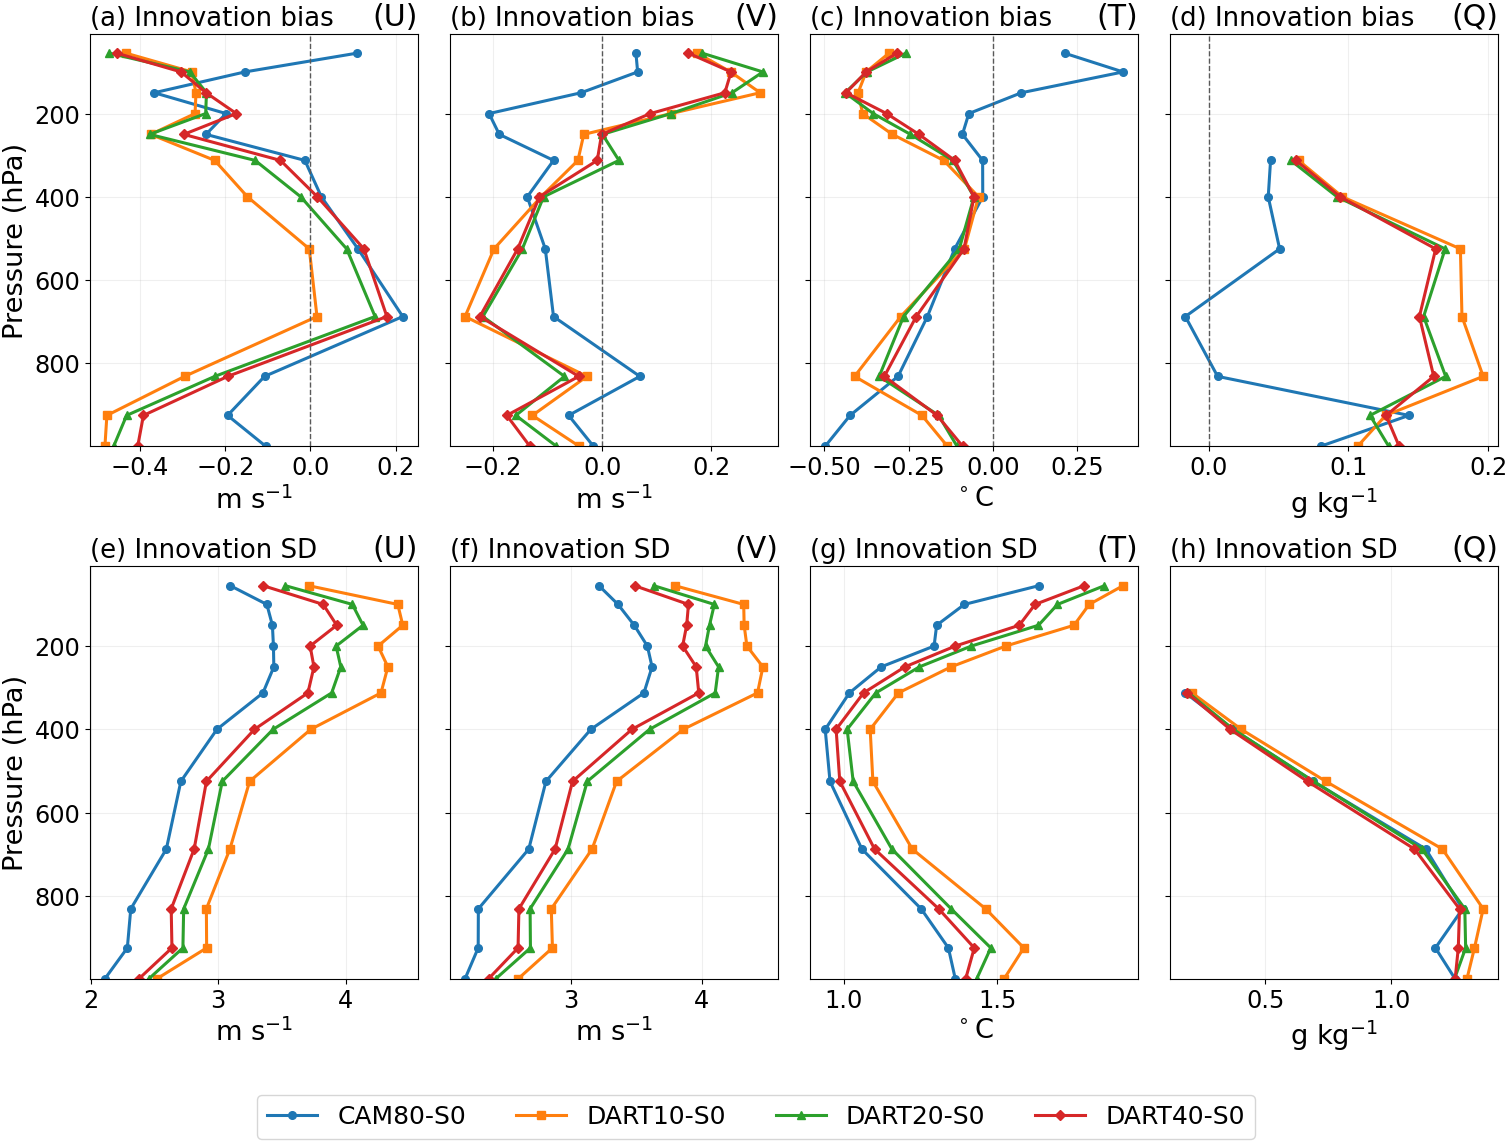

Generated 1 innovation-component figures. Inline display: common_s0 | Global.


In [33]:
generated_figures = {}
for (mode, region), profiles in processed_innovation_profiles.items():
    LOGGER.info("Plotting innovation profiles for %s | %s", mode, region)
    is_default_display = (
        mode == DISPLAY_MODE and region == DISPLAY_REGION
    )
    generated_figures[(mode, region)] = plot_innovation_profiles(
        profiles, mode, region,
        show=SHOW or (SHOW_DEFAULT and is_default_display),
        save=SAVE,
    )
print(
    f"Generated {sum(path is not None for path in generated_figures.values())} "
    "innovation-component figures. "
    f"Inline display: {DISPLAY_MODE} | {DISPLAY_REGION}."
)


## Interpretation guidance

- **Mean prior innovation** isolates the systematic component of observation-minus-prior mismatch; profiles closer to zero indicate less systematic disagreement.
- **Centered innovation SD** isolates random variability after removing the mean innovation. Because $\mathrm{RMSE}^2=\mu_d^2+\sigma_d^2$, it will resemble RMSE wherever the mean innovation is small. Present it as a bias/random decomposition, not as an independent error metric.
